In [1]:
#run only once!
%load_ext autoreload
%autoreload 2
import os
os.chdir(os.path.abspath(os.path.join(os.getcwd(), os.pardir)))

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from Schuster_Resonators.approx_Schuster import *
from CPW.cpw import *
import scipy.io as sc
import scipy.signal as sig

In [3]:
def db(x):
    return 20*np.log10(x)

def linear(x):
    return 10**(x/20)


def w0_from_S21(S21, w, prominence):
    dip , _ = sig.find_peaks(-S21, prominence = prominence)
    w0 = w[dip[0]]
    return w0



## MWO


In [ ]:
path = r'D:\AWR-MWO\202510-FC-Res'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())

['202510-SiRes-NbTiN-Tres-test.emp', '202510-SiRes-NbTiN-Tres-test.vin', 'DATA_SETS', 'TEMP', 'Tress-test10.mat', 'V11.mat']
['202510-SiRes-NbTiN-Tres-test', 'emp']
['202510-SiRes-NbTiN-Tres-test', 'vin']
['DATA_SETS']
['TEMP']
['Tress-test10', 'mat']
['V11', 'mat']
dict_keys(['Tress-test10', 'V11'])


In [5]:
def cut_off(data, f_min, f_max):
    mask = (data['freq'] >= f_min) & (data['freq'] <= f_max)
    return {'freq': data['freq'][mask], 'amp': data['amp'][mask]}

# d['GeRes-SiSubs-Al-v4'] = cut_off(d['GeRes-SiSubs-Al-v4'], 4.8e9, 5.2e9)

# V7

['202510-FC-Res.emp', '202510-FC-Res.vin', 'DATA_SETS', 'TEMP', 'V1.mat', 'V2.mat', 'V3.mat', 'V4.mat', 'V6.mat', 'V7.mat']
['202510-FC-Res', 'emp']
['202510-FC-Res', 'vin']
['DATA_SETS']
['TEMP']
['V1', 'mat']
['V2', 'mat']
['V3', 'mat']
['V4', 'mat']
['V6', 'mat']
['V7', 'mat']
dict_keys(['V1', 'V2', 'V3', 'V4', 'V6', 'V7'])


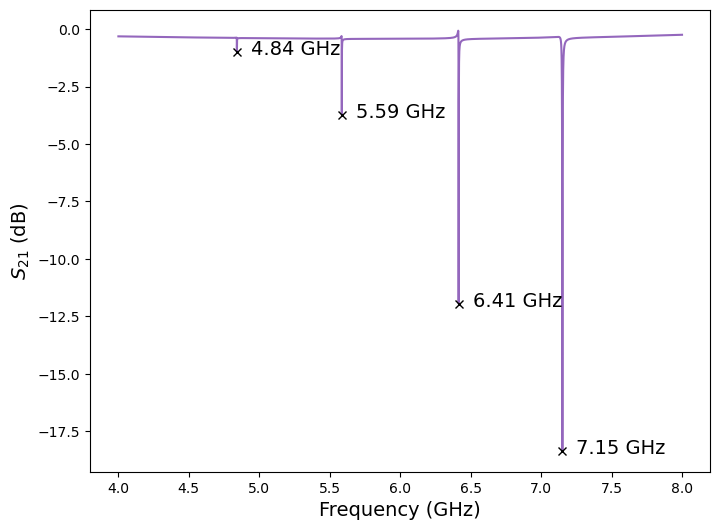

C0: [1.10459165e-13 1.01526957e-13 9.42072873e-14 8.83209254e-14]
Cc: [1.81908310e-15 2.43801779e-15 3.37908692e-15 4.98935436e-15]
Qc: [22311.2311488   9967.66896008  4240.8944312   1668.53870927]


In [20]:
version = 7



path = r'D:\AWR-MWO\202510-FC-Res'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)




name = f'V{version}'
filecsv = f'FC-V{version}.csv'


f0_si = []

ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.3)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
# ax.set_xlim(3, 9)
# ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
# ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-FC-Res\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 4


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V6

['202510-FC-Res.emp', '202510-FC-Res.vin', 'DATA_SETS', 'TEMP', 'V1.mat', 'V2.mat', 'V3.mat', 'V4.mat', 'V6.mat']
['202510-FC-Res', 'emp']
['202510-FC-Res', 'vin']
['DATA_SETS']
['TEMP']
['V1', 'mat']
['V2', 'mat']
['V3', 'mat']
['V4', 'mat']
['V6', 'mat']
dict_keys(['V1', 'V2', 'V3', 'V4', 'V6'])


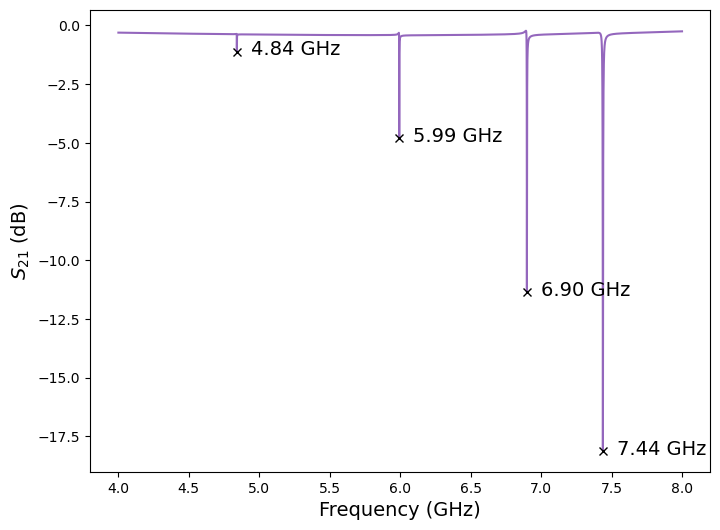

C0: [1.10361787e-13 9.87681430e-14 9.13994261e-14 8.68767518e-14]
Cc: [1.82456248e-15 2.40614987e-15 3.30502761e-15 4.90371820e-15]
Qc: [22159.27397032  9281.45762484  4000.10704051  1633.31467978]


In [19]:
version = 6



path = r'D:\AWR-MWO\202510-FC-Res'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)




name = f'V{version}'
filecsv = f'FC-V{version}.csv'


f0_si = []

ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.3)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
# ax.set_xlim(3, 9)
# ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
# ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-FC-Res\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 4


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V4

['202510-FC-Res.emp', '202510-FC-Res.vin', 'DATA_SETS', 'TEMP', 'V1.mat', 'V2.mat', 'V3.mat', 'V4.mat']
['202510-FC-Res', 'emp']
['202510-FC-Res', 'vin']
['DATA_SETS']
['TEMP']
['V1', 'mat']
['V2', 'mat']
['V3', 'mat']
['V4', 'mat']
dict_keys(['V1', 'V2', 'V3', 'V4'])


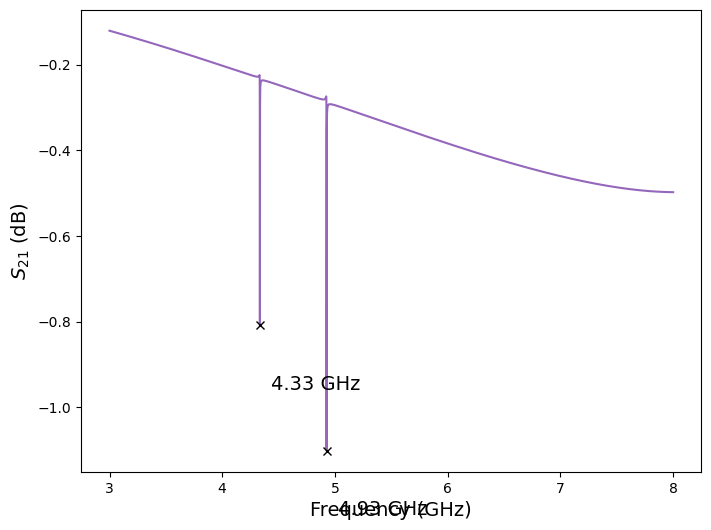

C0: [1.23368612e-13 1.16329283e-13]
Cc: [1.76660218e-15 1.72587101e-15]
Qc: [29448.5038238  29109.14861026]


In [18]:
version = 4



path = r'D:\AWR-MWO\202510-FC-Res'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)




name = f'V{version}'
filecsv = f'FC-V{version}.csv'


f0_si = []

ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.3)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
# ax.set_xlim(3, 9)
# ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
# ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-FC-Res\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 2


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si[:1], C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V3

['202510-FC-Res.emp', '202510-FC-Res.vin', 'DATA_SETS', 'TEMP', 'V1.mat', 'V2.mat', 'V3.mat']
['202510-FC-Res', 'emp']
['202510-FC-Res', 'vin']
['DATA_SETS']
['TEMP']
['V1', 'mat']
['V2', 'mat']
['V3', 'mat']
dict_keys(['V1', 'V2', 'V3'])


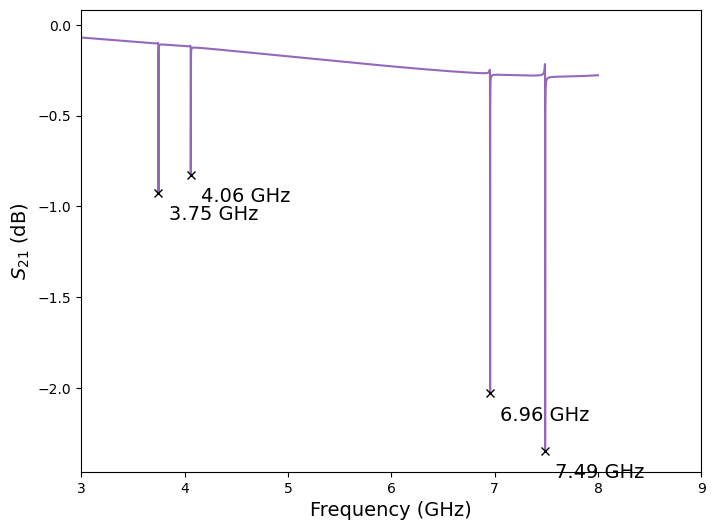

C0: [1.32609643e-13 1.30116667e-13]
Cc: [1.88165826e-15 1.82787010e-15]
Qc: [32271.97110437 33551.62442834]


In [13]:
version = 3



path = r'D:\AWR-MWO\202510-FC-Res'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)




name = f'V{version}'
filecsv = f'FC-V{version}.csv'


f0_si = []

ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.3)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(3, 9)
# ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
# ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-FC-Res\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 2


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si[:1], C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V2

['202510-FC-Res.emp', '202510-FC-Res.vin', 'DATA_SETS', 'TEMP', 'V1.mat', 'V2.mat']
['202510-FC-Res', 'emp']
['202510-FC-Res', 'vin']
['DATA_SETS']
['TEMP']
['V1', 'mat']
['V2', 'mat']
dict_keys(['V1', 'V2'])


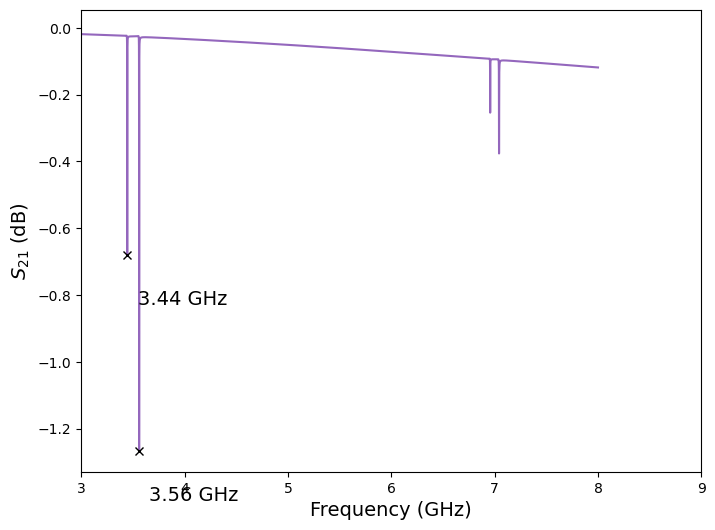

C0: [1.10857856e-13 1.09884991e-13]
Cc: [1.97384899e-15 1.95948657e-15]
Qc: [26764.86551188 26049.73409869]


In [11]:
path = r'D:\AWR-MWO\202510-FC-Res'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V2'
filecsv = 'FC-V2.csv'


f0_si = []

ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.3)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(3, 9)
# ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
# ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-FC-Res\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 2


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')

# V1

['202510-FC-Res.emp', 'DATA_SETS', 'TEMP', 'V1.mat']
['202510-FC-Res', 'emp']
['DATA_SETS']
['TEMP']
['V1', 'mat']
dict_keys(['V1'])


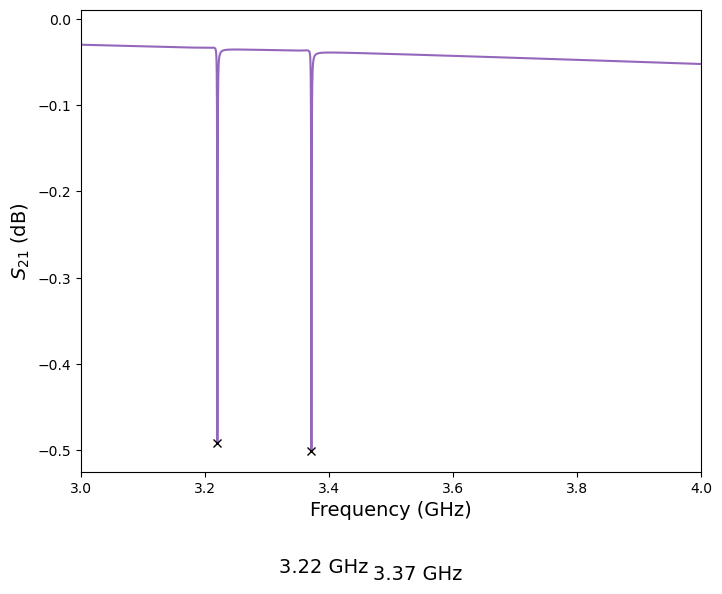

C0: [1.19999103e-13 1.18432905e-13]
Cc: [1.58882526e-15 1.52899851e-15]
Qc: [47622.62946925 48452.99176307]


In [7]:
path = r'D:\AWR-MWO\202510-FC-Res'
file_list = os.listdir(path)
print(file_list)
d = {}

# Load the data
for file in file_list:
    name = file.split('.')
    print(name)
    if name[-1] != 'mat':
        continue
    name = name[0]
    file_path = os.path.join(path, file)
    mat_contents = sc.loadmat(file_path)
    freq = mat_contents['X\x00\x00\x00\x00\x00\x00\x00'][0]
    amp = mat_contents['Y\x00\x00\x00\x00\x00\x00\x00'][0]    
    d[name] = {'freq': freq, 'amp': amp}

print(d.keys())



fig, ax = plt.subplots(1, 1, figsize=(8, 6))
plt.subplots_adjust(hspace=0.5)





name = 'V1'
filecsv = 'FC-V1.csv'


f0_si = []
ax.plot(d[name]['freq']*1e-9, d[name]['amp'], color ='tab:purple')
peak, _ = sig.find_peaks(-d[name]['amp'], prominence = 0.2)
f0 = d[name]['freq'][peak]*1e-9
ax.plot(d[name]['freq'][peak]*1e-9, d[name]['amp'][peak], 'x', color='black')
for i in range(len(peak)):
    f0_si.append(f0[i])
    ax.text(d[name]['freq'][peak[i]]*1e-9+0.1, d[name]['amp'][peak[i]]-0.15, f'{f0[i]:.2f} GHz', fontsize=14, color='black')

# ax.set_title('Si substrate')
ax.set_xlabel('Frequency (GHz)', fontsize=14)
ax.set_ylabel('$S_{21}$ (dB)', fontsize=14)
ax.set_xlim(3, 4)
# ax.set_yticklabels(labels = np.arange(-9,0.1,1),fontsize=12)
# ax.set_xticklabels(labels = np.arange(4,8.1,0.5),fontsize=12)
plt.show()





path = r'D:\Ansys-Projects\202510-FC-Res\exports'
file_list = os.listdir(path)
# print(file_list)

NoR = 2


data = -1*pd.read_csv(os.path.join(path, filecsv), skiprows=8, nrows = NoR+2)

C0 = []
Cc = []
for i in range(NoR):
    C0.append(data.iloc[i+2,1]*1e-15)
    Cc.append(data.iloc[i+2,2]*1e-15)

C0 = np.array(C0)
Cc = np.array(Cc)
f0_si = np.array(f0_si)
# print(f0_si)

#Qc
def Qc(f0, C0, Cc):
    return (C0+Cc)/(2*np.pi*1e9*f0*50*Cc**2)

Qc_Tres = Qc(f0_si, C0, Cc)
print(f'C0: {C0}')
print(f'Cc: {Cc}')
print(f'Qc: {Qc_Tres}')